In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

In [ ]:
# DON'T RUN THIS
import pandas as pd
import requests

all_drugs = []
num = 0

while True:
    drug_data = requests.get(f"https://api.fda.gov/drug/label.json?limit=1000&skip={num}").json()
    
    if 'results' not in drug_data:
        break
    
    all_drugs.extend(drug_data['results'])
    num += 1000

drug_df = pd.json_normalize(all_drugs)
drug_df.to_csv('drug.csv', index=False)

In [73]:
# RUN THIS
df = pd.read_csv("drug.csv", low_memory=False)
df

,effective_time,inactive_ingredient,purpose,keep_out_of_reach_of_children,warnings,questions,spl_product_data_elements,version,dosage_and_administration,pregnancy_or_breast_feeding,...,health_care_provider_letter_table,guaranteed_analysis_of_feed,troubleshooting,nonteratogenic_effects_table,safe_handling_warning_table,nursing_mothers_table,spl_indexing_data_elements,teratogenic_effects_table,health_claim_table,spl_indexing_data_elements_table
0,20210902,['INACTIVE INGREDIENTS Sucrose'],"['USES USES: Temporary Relief - Acne, Boils* *...",['Keep this and all medication out of reach of...,['WARNINGS This product is to be used for self...,['QUESTIONS OR COMMENTS www.Rxhomeo.com | 1.88...,['SILICEA SILICEA SUCROSE SILICON DIOXIDE SILI...,2,"['DOSAGE Adults- Take 4 or 6 Pellets by mouth,...","['As with any drug, if you are pregnant, or nu...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20150109,"['INGREDIENTS: TALC, POLYMETHYL METHACRYLATE, ...",['Purpose Sunscreen'],['Keep out of reach of children If product is ...,['Warnings For external use only.'],NaN,['CHANTECAILLE PROTECTION NATURELLE BRONZE SPF...,4,['Directions Protection Naturelle SPF 46 PA+++...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20250102,"['Inactive ingredients pareth 25-9, purified w...",['Purpose First aid Antiseptic'],"['Keep out of reach of children If swallowed, ...",['Warnings For external use only'],NaN,['Betadine POVIDONE-IODINE POVIDONE-IODINE IOD...,1,['Directions clean the affected area spray a s...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20230802,['INACTIVE INGREDIENTS Sucrose/Lactose'],['USES To relieve the symptoms of itching.'],['KEEP OUT OF REACH OF CHILDREN Keep this and ...,['STOP USE AND ASK DOCTOR If symptoms persist/...,NaN,['Mezereum DAPHNE MEZEREUM BARK SUCROSE LACTOS...,3,['DIRECTIONS Adults: Dissolve 3 to 5 under the...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20230905,NaN,NaN,NaN,['WARNINGS NOT FOR INJECTION. Ofloxacin ophtha...,NaN,['Ofloxacin Ofloxacin OFLOXACIN OFLOXACIN Sodi...,7,['DOSAGE AND ADMINISTRATION The recommended do...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25995,20240611,"['Water (Aqua, Eau), Fragrance (Parfum), Carbo...",['Purpose Antiseptic'],"['Keep out of reach of children. If swallowed,...",['Warnings Flammable: Keep away from flame or ...,NaN,['Anti Bacterial Hand Gel Flower Child Alcohol...,1,['Directions Rub a dime sized drop into hands.'],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25996,20250219,NaN,NaN,NaN,['WARNINGS General In patients on corticostero...,NaN,['Prednisone Prednisone LACTOSE MONOHYDRATE CE...,10,['DOSAGE & ADMINISTRATION The initial dosage o...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25997,20240611,"['Water (Aqua, Eau), Fragrance (Parfum), Carbo...",['Purpose Antiseptic'],"['Keep out of reach of children. If swallowed,...",['Warnings Flammable: Keep away from flame or ...,NaN,['Anti Bacterial Hand Gel Fresh Amalfi Lemon A...,1,['Directions Rub a dime sized drop into hands.'],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25998,20240611,['Inactive ingredients Aloe Barbadensis (Aloe ...,['Purpose Sunscreen'],"['Keep out of reach of children. If swallowed,...",['Warnings For external use only Do not use on...,NaN,"['Matte Sunscreen SPF 50 Titanium Dioxide, Zin...",1,['Directions • apply liberally 15 minutes befo...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
df.shape

(26000, 165)

In [75]:
df.columns

Index(['effective_time', 'inactive_ingredient', 'purpose',
       'keep_out_of_reach_of_children', 'warnings', 'questions',
       'spl_product_data_elements', 'version', 'dosage_and_administration',
       'pregnancy_or_breast_feeding',
       ...
       'health_care_provider_letter_table', 'guaranteed_analysis_of_feed',
       'troubleshooting', 'nonteratogenic_effects_table',
       'safe_handling_warning_table', 'nursing_mothers_table',
       'spl_indexing_data_elements', 'teratogenic_effects_table',
       'health_claim_table', 'spl_indexing_data_elements_table'],
      dtype='object', length=165)

In [76]:
# Dup Check

# All Features Values Shared
print("Full Dups:", df.duplicated().sum())

# UID (doc, product) shared
print("Dup 'id' values:    ", df['id'].duplicated().sum())
print("Dup 'set_id'(product) values:", df['set_id'].duplicated().sum())

# Drop triggered from above
_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f" Pre-Dedup Ct. : {_before} | Post-Dedup Ct. : {len(df)} | (Dropped {_before - len(df)} Dups)")

Full Dups: 0
Dup 'id' values:     0
Dup 'set_id'(product) values: 0
 Pre-Dedup Ct. : 26000 | Post-Dedup Ct. : 26000 | (Dropped 0 Dups)


In [77]:
drug_df = df[['inactive_ingredient', 'purpose', 'warnings',
       'spl_product_data_elements', 'dosage_and_administration',
       'pregnancy_or_breast_feeding', 'stop_use', 'storage_and_handling',
       'do_not_use', 'active_ingredient', 'openfda.brand_name',
       'openfda.manufacturer_name', 'openfda.product_type', 'openfda.route',
       'openfda.package_ndc', 'when_using', 'ask_doctor',
       'clinical_studies',
       'adverse_reactions']]

In [78]:
drug_df.shape

(26000, 19)

In [79]:
drug_df.columns

Index(['inactive_ingredient', 'purpose', 'warnings',
       'spl_product_data_elements', 'dosage_and_administration',
       'pregnancy_or_breast_feeding', 'stop_use', 'storage_and_handling',
       'do_not_use', 'active_ingredient', 'openfda.brand_name',
       'openfda.manufacturer_name', 'openfda.product_type', 'openfda.route',
       'openfda.package_ndc', 'when_using', 'ask_doctor', 'clinical_studies',
       'adverse_reactions'],
      dtype='object')

In [80]:
drug_df['inactive_ingredient'] = drug_df['inactive_ingredient'].str.lower().str.replace("ingredients", '').str.replace("inactive", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['inactive_ingredient']

/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_28944/1619720799.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['inactive_ingredient'] = drug_df['inactive_ingredient'].str.lower().str.replace("ingredients", '').str.replace("inactive", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()


0                                                  sucrose
1        talc, polymethyl methacrylate, vinyl dimethico...
2        pareth 25-9, purified water, sodium hydroxide ...
3                                          sucrose/lactose
4                                                      NaN
                               ...                        
25995    water (aqua, eau), fragrance (parfum), carbome...
25996                                                  NaN
25997    water (aqua, eau), fragrance (parfum), carbome...
25998    aloe barbadensis (aloe vera) leaf extract, alu...
25999    water (aqua, eau), fragrance (parfum), carbome...
Name: inactive_ingredient, Length: 26000, dtype: object

In [81]:
drug_df['purpose'] = drug_df['purpose'].str.lower().str.replace("uses", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['purpose']

/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_28944/2431895778.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['purpose'] = drug_df['purpose'].str.lower().str.replace("uses", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()


0        temporary relief - acne, boils* * claims based...
1                                        purpose sunscreen
2                             purpose first aid antiseptic
3                      to relieve the symptoms of itching.
4                                                      NaN
                               ...                        
25995                                   purpose antiseptic
25996                                                  NaN
25997                                   purpose antiseptic
25998                                    purpose sunscreen
25999                                   purpose antiseptic
Name: purpose, Length: 26000, dtype: object

In [82]:
drug_df['warnings'] = drug_df['warnings'].str.lower().str.replace("warnings", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['warnings']

/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_28944/1449303301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['warnings'] = drug_df['warnings'].str.lower().str.replace("warnings", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()


0        this product is to be used for self-limiting c...
1                                   for external use only.
2                                    for external use only
3        stop use and ask doctor if symptoms persist/wo...
4        not for injection. ofloxacin ophthalmic soluti...
                               ...                        
25995    flammable keep away from flame or high heat., ...
25996    general in patients on corticosteroid therapy ...
25997    flammable keep away from flame or high heat., ...
25998    for external use only do not use on damaged or...
25999    flammable keep away from flame or high heat., ...
Name: warnings, Length: 26000, dtype: object

In [83]:
drug_df['spl_product_data_elements'] = drug_df['spl_product_data_elements'].str.lower().str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['spl_product_data_elements'] = drug_df['spl_product_data_elements'].apply(lambda x: ' '.join(dict.fromkeys(str(x).split())))
drug_df['spl_product_data_elements']

/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_28944/339225787.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['spl_product_data_elements'] = drug_df['spl_product_data_elements'].str.lower().str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_28944/339225787.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['spl_product_data_elements'] = drug_df['spl_pr

0                          silicea sucrose silicon dioxide
1        chantecaille protection naturelle bronze spf 4...
2        betadine povidone-iodine iodine c12-15 pareth-...
3               mezereum daphne bark sucrose lactose white
4        ofloxacin sodium chloride hydrochloric acid hy...
                               ...                        
25995    anti bacterial hand gel flower child alcohol w...
25996    prednisone lactose monohydrate cellulose, micr...
25997    anti bacterial hand gel fresh amalfi lemon alc...
25998    matte sunscreen spf 50 titanium dioxide, zinc ...
25999    anti bacterial hand gel fresh cut lilacs alcoh...
Name: spl_product_data_elements, Length: 26000, dtype: object

In [84]:
drug_df['active_ingredient'] = drug_df['active_ingredient'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
drug_df['active_ingredient'] = drug_df['active_ingredient'].str.replace("in each gram", '').str.replace("(", '').str.replace(")", '').str.strip()
drug_df['active_ingredient']

/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_28944/4127942404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['active_ingredient'] = drug_df['active_ingredient'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_28944/4127942404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

0                    ingredient silicea hpus 2x and higher
1        bronze   titanium dioxide 2 %, ethylhexyl meth...
2                povidone-iodine, 5% 0.5% available iodine
3                                                 mezereum
4                                                      NaN
                               ...                        
25995                               ingredient alcohol 71%
25996                                                  NaN
25997                               ingredient alcohol 71%
25998               titanium dioxide 5.8% zinc oxide 14.4%
25999                               ingredient alcohol 71%
Name: active_ingredient, Length: 26000, dtype: object

In [85]:
drug_df['active_ingredient'] = drug_df['active_ingredient'].fillna(drug_df['spl_product_data_elements'])

/var/folders/kf/rgl3jr7124178zb5yq4fmjdm0000gp/T/ipykernel_28944/2430981737.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_df['active_ingredient'] = drug_df['active_ingredient'].fillna(drug_df['spl_product_data_elements'])


In [86]:
drug_df['active_ingredient'].value_counts()
drug_df = drug_df.drop(columns = 'spl_product_data_elements')

In [87]:
drug_df['dosage_and_administration'] = drug_df['dosage_and_administration'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
drug_df['dosage_and_administration'] = drug_df['dosage_and_administration'].str.replace('dosage and administration', '').str.replace('directions', '').str.replace('dosage', '').str.replace('•', '').str.replace('"', '').str.strip()
drug_df['dosage_and_administration']

0        adults- take 4 or 6 pellets by mouth, three ti...
1        protection naturelle spf 46 pa+++ powder can b...
2        clean the affected area spray a small amount o...
3        adults dissolve 3 to 5 under the tongue three ...
4        the recommended  regimen for the treatment of ...
                               ...                        
25995                    rub a dime sized drop into hands.
25996    & administration the initial  of prednisone ma...
25997                    rub a dime sized drop into hands.
25998    apply liberally 15 minutes before sun exposure...
25999                    rub a dime sized drop into hands.
Name: dosage_and_administration, Length: 26000, dtype: object

In [88]:
drug_df.loc[drug_df['pregnancy_or_breast_feeding'].notna(), 'pregnancy_or_breast_feeding'] = 'Bad'
drug_df['pregnancy_or_breast_feeding'] = drug_df['pregnancy_or_breast_feeding'].fillna('Fine')
drug_df['pregnancy_or_breast_feeding']

0         Bad
1        Fine
2        Fine
3        Fine
4        Fine
         ... 
25995    Fine
25996    Fine
25997    Fine
25998    Fine
25999    Fine
Name: pregnancy_or_breast_feeding, Length: 26000, dtype: object

In [89]:
def categorize_stop_use(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'rash' in text:
        return 'rash'
    elif 'allergic' in text:
        return 'allergic reaction'
    elif 'irritat' in text:
        return 'irritation'
    elif 'rectal bleeding' in text or 'bowel' in text:
        return 'rectal bleeding or bowel movement problems'
    elif 'dry' in text:
        return 'dry'
    elif 'days' in text or 'week' in text or 'persist' in text or 'improve' in text or 'regular' in text:
        return 'symptoms persist after some time'
    elif 'do not use' in text:
        return np.nan
    else:
        return 'other'

drug_df['stop_use'] = drug_df['stop_use'].apply(lambda x: categorize_stop_use(x))
drug_df['stop_use'].value_counts()

stop_use
rash                                          3399
symptoms persist after some time              2481
irritation                                    1691
allergic reaction                              536
rectal bleeding or bowel movement problems     341
other                                          254
dry                                              6
Name: count, dtype: int64

In [90]:
drug_df['storage_and_handling'] = drug_df['storage_and_handling'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
drug_df['storage_and_handling'] = drug_df['storage_and_handling'].str.replace('other information', '')
drug_df['storage_and_handling']

0                       storage store in a cool dark place
1                                                      NaN
2         store at 25⁰c (77⁰f); excursions permitted be...
3                                                      NaN
4                                                      NaN
                               ...                        
25995                                                  NaN
25996                                                  NaN
25997                                                  NaN
25998                                                  NaN
25999                                                  NaN
Name: storage_and_handling, Length: 26000, dtype: object

In [91]:
drug_df['do_not_use'] = drug_df['do_not_use'].str.lower().str.replace('do not use', '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['do_not_use'] = drug_df['do_not_use'].fillna('use')
drug_df['do_not_use']

0        if capseal is broken or missing. close the cap...
1                                                      use
2        in the eyes over large areas of the body if yo...
3                                                      use
4                                                      use
                               ...                        
25995                                                  use
25996                                                  use
25997                                                  use
25998                            on damaged or broken skin
25999                                                  use
Name: do_not_use, Length: 26000, dtype: object

In [92]:
drug_df['openfda.brand_name'] = drug_df['openfda.brand_name'].str.lower().str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['brand_name'] = drug_df['openfda.brand_name']
drug_df = drug_df.drop(columns = ['openfda.brand_name'])
drug_df['brand_name']

0                                           silicea
1                                               NaN
2                                          betadine
3                                               NaN
4                                               NaN
                            ...                    
25995          anti bacterial hand gel flower child
25996                                    prednisone
25997    anti bacterial hand gel fresh amalfi lemon
25998                                           NaN
25999      anti bacterial hand gel fresh cut lilacs
Name: brand_name, Length: 26000, dtype: object

In [93]:
drug_df['openfda.manufacturer_name'] = drug_df['openfda.manufacturer_name'].str.lower().str.replace(".", '').str.replace("llc", '').str.replace(",", '').str.replace("inc", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['openfda.manufacturer_name'] = drug_df['openfda.manufacturer_name'].str.replace("co", '').str.replace("ltd", '')
drug_df['manufacturer_name'] = drug_df['openfda.manufacturer_name']
drug_df = drug_df.drop(columns = ['openfda.manufacturer_name'])
drug_df['manufacturer_name']

0        rxhomeo private limited dba rxhomeo
1                                        NaN
2                 atlantis nsumer healthcare
3                                        NaN
4                                        NaN
                        ...                 
25995                      bath & body works
25996                  pd-rx pharmaceuticals
25997                      bath & body works
25998                                    NaN
25999                      bath & body works
Name: manufacturer_name, Length: 26000, dtype: object

In [94]:
def categorize_product_type(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'otc' in text:
        return 'OTC'
    elif 'prescription' in text:
        return 'prescription'
    elif 'cellular therapy' in text:
        return 'cellular therapy'

drug_df['product_type'] = drug_df['openfda.product_type'].apply(lambda x: categorize_product_type(x))
drug_df = drug_df.drop(columns = ['openfda.product_type'])
drug_df['product_type']

0                 OTC
1                 NaN
2                 OTC
3                 NaN
4                 NaN
             ...     
25995             OTC
25996    prescription
25997             OTC
25998             NaN
25999             OTC
Name: product_type, Length: 26000, dtype: object

In [95]:
drug_df['openfda.route'] = drug_df['openfda.route'].str.lower().str.replace(".", '').str.replace("llc", '').str.replace(",", '').str.replace("inc", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['route'] = drug_df['openfda.route']
drug_df = drug_df.drop(columns = ['openfda.route'])
drug_df['route']

0           oral
1            NaN
2        topical
3            NaN
4            NaN
          ...   
25995    topical
25996       oral
25997    topical
25998        NaN
25999    topical
Name: route, Length: 26000, dtype: object

In [96]:
def categorize_when_using(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'eyes' in text:
        return 'keep out of eyes'
    elif 'alcohol' in text:
        return 'avoid alcoholic beverages'
    elif 'caffine' in text:
        return 'avoid caffine'
    elif 'more than' in text or 'dosage' in text or 'dose' in text:
        return 'do not take more than directed'
    elif 'food or milk' in text:
        return 'take with food or milk if stomach upset'
    else:
        return 'other'

drug_df['when_using'] = drug_df['when_using'].apply(lambda x: categorize_when_using(x))
drug_df['when_using'].value_counts()

when_using
keep out of eyes                           4450
other                                      1042
do not take more than directed             1004
avoid alcoholic beverages                   736
take with food or milk if stomach upset     178
Name: count, dtype: int64

In [97]:
def categorize_ask_doctor(text):
    if pd.isna(text) or text == "['']":
        return np.nan
    text = text.lower()
    if 'liver' in text and 'kidney' in text:
        return 'if you have liver or kidney disease'
    elif 'liver' in text and not 'kidney' in text:
        return 'if you have liver disease'
    elif 'kidney' in text and not 'liver' in text:
        return 'if you have kidney disease'
    elif 'breathing' in text:
        return 'if you have breathing issues'
    elif 'fever mucus' in text:
        return 'if you have fever mucus in stool'
    else:
        return 'other'

drug_df['ask_doctor'] = drug_df['ask_doctor'].apply(lambda x: categorize_ask_doctor(x))
drug_df['ask_doctor'].value_counts()

ask_doctor
other                                  2310
if you have liver disease               834
if you have liver or kidney disease     696
if you have kidney disease              375
if you have breathing issues            364
if you have fever mucus in stool         47
Name: count, dtype: int64

In [98]:
drug_df['clinical_studies'] = drug_df['clinical_studies'].str.replace('14', '').str.replace('CLINICAL', '').str.replace('TRIALS', '').str.replace('STUDIES', '').str.lower().str.replace(".", '').str.replace(",", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['clinical_studies']

0                                                      NaN
1                                                      NaN
2                                                      NaN
3                                                      NaN
4        clinical studies conjunctivitis in a randomize...
                               ...                        
25995                                                  NaN
25996                                                  NaN
25997                                                  NaN
25998                                                  NaN
25999                                                  NaN
Name: clinical_studies, Length: 26000, dtype: object

In [99]:
drug_df['adverse_reactions'] = drug_df['adverse_reactions'].str.replace('ADVERSE', '').str.replace('REACTIONS', '').str.replace('6', '').str.lower().str.replace(".", '').str.replace(",", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['adverse_reactions']

0                                                      NaN
1                                                      NaN
2                                                      NaN
3                                                      NaN
4        ophthalmic use the most frequently reported dr...
                               ...                        
25995                                                  NaN
25996    fluid and electrolyte disturbances sodium rete...
25997                                                  NaN
25998                                                  NaN
25999                                                  NaN
Name: adverse_reactions, Length: 26000, dtype: object

In [100]:
"""
WHAT I'M (RYAN) LOOKING TO FIND:

Is the market ruled by a few giants (concentrated) or split among many small players (fragmented)?

I want to quantify
- Top 10 Biggest Drug Makers, and What % of Total Labeled Share they account for
- How many small makers are there (just 1-2 products)
- Herfindahl-Hirschman Index (HHI) -- concentration score


"""

"\nWHAT I'M (RYAN) LOOKING TO FIND:\n\nIs the market ruled by a few giants (concentrated) or split among many small players (fragmented)?\n\nI want to quantify\n- Top 10 Biggest Drug Makers, and What % of Total Labeled Share they account for\n- How many small makers are there (just 1-2 products)\n- Herfindahl-Hirschman Index (HHI) -- concentration score\n\n\n"

In [101]:
makers_df = drug_df.copy() # deep copy

_base_len = len(makers_df) # pre-removal

makers_df = makers_df["manufacturer_name"].dropna() # remove drugs w/out labels

_post_len = len(makers_df) # post-removal

print(f"Total Drugs : {_base_len} | Labeled Drugs : {_post_len} | Unlabeled % : {((_base_len - _post_len) / _base_len) * 100}%")

Total Drugs : 26000 | Labeled Drugs : 9321 | Unlabeled % : 64.14999999999999%


In [102]:
# Drugs Per Company
cts = makers_df.value_counts()

cts.head()

manufacturer_name
bryant ranch prepack                   422
a-s medication solutions               281
proficient rx lp                       132
remedyrepack                           127
rxhomeo private limited dba rxhomeo    123
Name: count, dtype: int64

In [103]:
# Fractionally

shares = makers_df.value_counts(normalize=True) * 100

_t1 = shares.iloc[0]        #1
_t5 = shares.head(5).sum()  # top 5
_t10 = shares.head(10).sum() # top 10

print(f"Top Manufacturer Market Share : {_t1}% | Top 5 Manufacturers\' Market Share : {_t5}% | Top 10 Manufacturers\' Market Share : {_t10}%")


Top Manufacturer Market Share : 4.527411221971891% | Top 5 Manufacturers' Market Share : 11.640381933268964% | Top 10 Manufacturers' Market Share : 17.12262632764725%


In [104]:
# How Many Small?

solo_ct = (cts <= 1).sum()
solo_pct = (solo_ct / cts.shape[0]) * 100

print(f"Manufactuers With 1 Product : {solo_ct}x | {solo_pct}%")
# Really Interesting!!! almost 1/2 of drug manufacturers are small 1 product companies

# Bin into ranges

_ul = 10**9 # really big upper limit for binning
buckets = pd.cut(cts, bins=[0,1,3,10,50,_ul],labels=["1","2-3","4-10","11-50","50+"])
buckets.value_counts().sort_index()

Manufactuers With 1 Product : 833x | 48.971193415637856%


count
1        833
2-3      408
4-10     283
11-50    155
50+       22
Name: count, dtype: int64

In [105]:
hhi = (shares ** 2).sum() 
print(f" HHI: {hhi}")


_max_score = 10_000
eq_size_hypo = _max_score / hhi
print(f" Market Behaves like {eq_size_hypo} Competitors -- No One Really Dominates")



"""
Intepretation:

HHI <=> std. measure of market concentration (does 1 big player dominate, or a bunch of mini players split the pie)

scale (recall squared):

PLAYER(S)      PERCENT SHARE        SCORE
   1               100               10_000
   2                50                2_500
   ........................................
   1000s             ~0                 0


We're on the very low end of the spectrum where no one really has a grip.

"""

 HHI: 59.23996697967742
 Market Behaves like 168.80495567174358 Competitors -- No One Really Dominates


"\nIntepretation:\n\nHHI <=> std. measure of market concentration (does 1 big player dominate, or a bunch of mini players split the pie)\n\nscale (recall squared):\n\nPLAYER(S)      PERCENT SHARE        SCORE\n   1               100               10_000\n   2                50                2_500\n   ........................................\n   1000s             ~0                 0\n\n\nWe're on the very low end of the spectrum where no one really has a grip.\n\n"

In [106]:
_t10 = cts.head(10).index
mix = pd.crosstab(drug_df["manufacturer_name"],
                  drug_df["product_type"]).loc[_t10]
mix

product_type,OTC,cellular therapy,prescription
manufacturer_name,,,
bryant ranch prepack,10,0,412
a-s medication solutions,27,0,254
proficient rx lp,8,0,124
remedyrepack,0,0,127
rxhomeo private limited dba rxhomeo,123,0,0
nop d/b/a/ unilever,113,0,0
preferred pharmaceuticals,17,0,92
nucare pharmaceuticals,7,0,101
pd-rx pharmaceuticals,3,0,91


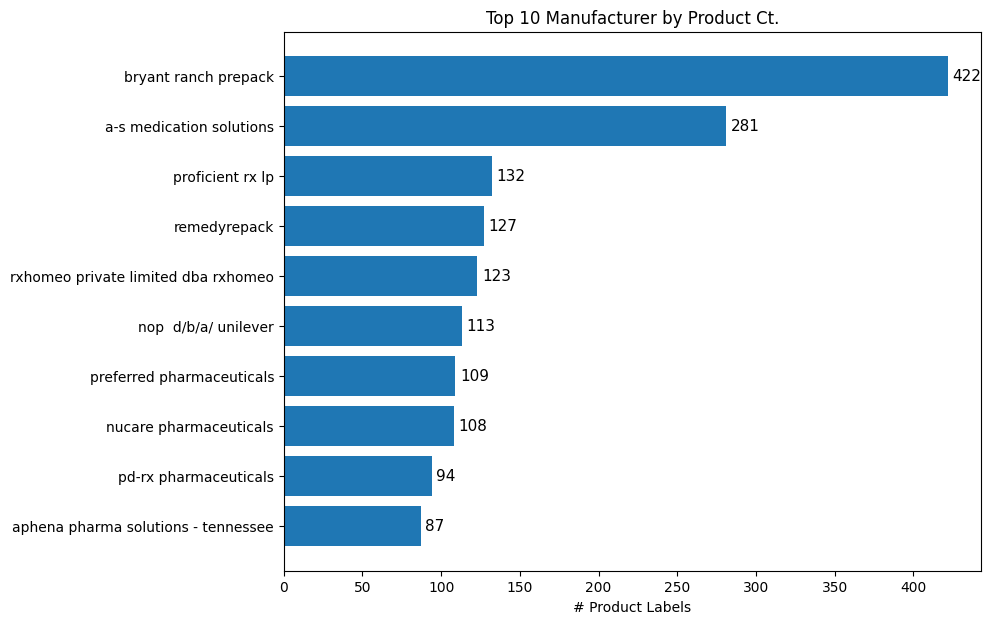

'\nMain observation is that... 1,2 are really not that big.\nAnd the 8-10 are insanely similar, adding to our hypotheis of there not really being a substantial victor with notable market share dominance\n'

In [107]:
# Charts to Visualize What We've Been Peicing together

_t10 = cts.head(10).sort_values()

fig, ax = plt.subplots(figsize=(9,7)) # make it wide; long names...
ax.barh(_t10.index, _t10.values)
ax.set_xlabel("# Product Labels")
ax.set_title("Top 10 Manufacturer by Product Ct.")

# write the value at the end of each bar
for i, v in enumerate(_t10.values):
    ax.text(v + 3, i, str(v), va="center", fontsize=11)

plt.show()

"""
Main observation is that... 1,2 are really not that big.
And the 8-10 are insanely similar, adding to our hypotheis of there not really being a substantial victor with notable market share dominance
"""

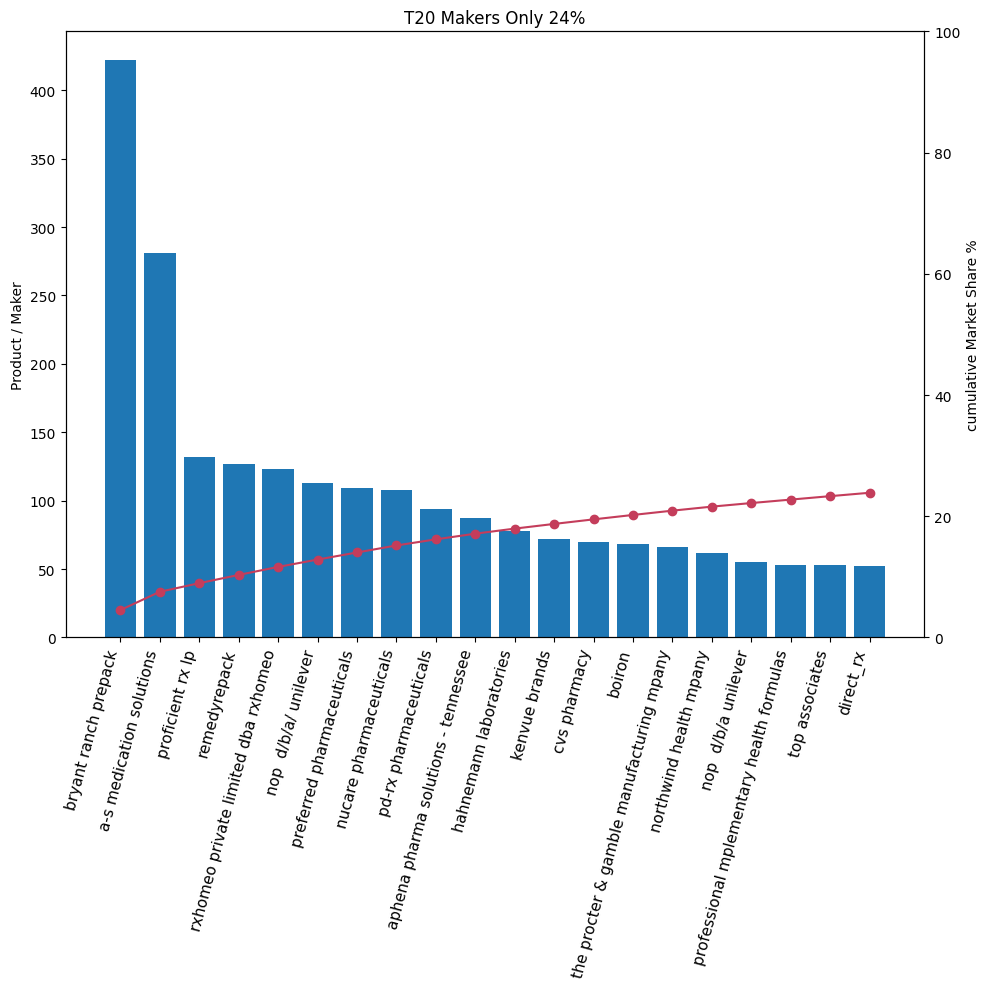

'\nEven all top 20 cumulative dont take a quarter....\n'

In [108]:
_t20 = cts.head(20)
cum_percent = (_t20.cumsum() / len(makers_df)) * 100

fig, ax = plt.subplots(figsize=(10, 10))
                               
ax.bar(range(len(_t20)), _t20.values) 
ax.set_ylabel("Product / Maker")
ax.set_xticks(range(len(_t20)))
ax.set_xticklabels(_t20.index, rotation=75, ha="right", fontsize=11)

ax2 = ax.twinx()                        
ax2.plot(range(len(_t20)), cum_percent.values, color="#c43d5b", marker="o")
ax2.set_ylabel("cumulative Market Share %")
ax2.set_ylim(0, 100)

ax.set_title("T20 Makers Only 24%")
plt.tight_layout(); plt.show()

"""
Even all top 20 cumulative dont take a quarter....
"""

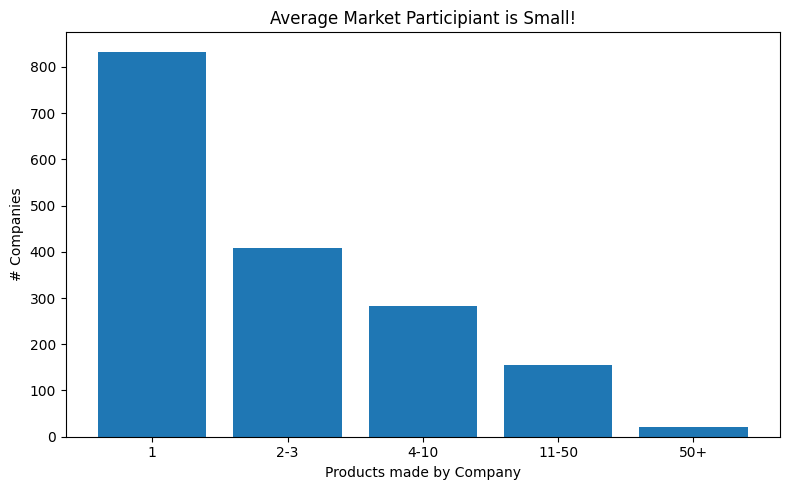

In [109]:
order = ["1","2-3","4-10","11-50","50+"]
band = buckets.value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(band.index, band.values)
ax.set_xlabel("Products made by Company")
ax.set_ylabel("# Companies")
ax.set_title("Average Market Participiant is Small!")
plt.tight_layout(); plt.show()

In [110]:
"""
Summary

This market is not ruled by a few giants, but instead split amongst a mass of small 1-2 product companies, and a few bigger players with their own caveats.
Our key evidence in making this claim is three fold:
1)  Top maker is only ~4.5%
2) top 20 combined STILL dont even hit a quarter (24%).
3) HHI of ~59 is way down at the bottom of the scale (recall 10_000 = monopoly), which
   is like ~170 equal-sized makers splitting the pie -- no one really has a grip.

The Aforementioned Caveat with the few biggest players...
 the "biggest" names arent even real brands, they're repackagers.
(Bryant Ranch Prepack, A-S Medication Solutions, Proficient Rx, RemedyRepack, NuCare...).

They just re-bottle existing drugs so they rack up a ton of labels without actually producing anything."""


'\nSummary\n\nThis market is not ruled by a few giants, but instead split amongst a mass of small 1-2 product companies, and a few bigger players with their own caveats.\nOur key evidence in making this claim is three fold:\n1)  Top maker is only ~4.5%\n2) top 20 combined STILL dont even hit a quarter (24%).\n3) HHI of ~59 is way down at the bottom of the scale (recall 10_000 = monopoly), which\n   is like ~170 equal-sized makers splitting the pie -- no one really has a grip.\n\nThe Aforementioned Caveat with the few biggest players...\n the "biggest" names arent even real brands, they\'re repackagers.\n(Bryant Ranch Prepack, A-S Medication Solutions, Proficient Rx, RemedyRepack, NuCare...).\n\nThey just re-bottle existing drugs so they rack up a ton of labels without actually producing anything.'

In [111]:
""""
William's Correlation Analysis

Is there a correlation between the length of a drug's warning section and the length of its dosage and administrtion instructions?

My goal is to determine whether drugs with longer warning sections will also tend to include longer dosage instructions. I'm going to compute the Pearson correlation coefficient and make a scatter plot to visualize the results and see if there exists a relationship
"""

'"\nWilliam\'s Correlation Analysis\n\nIs there a correlation between the length of a drug\'s warning section and the length of its dosage and administrtion instructions?\n\nMy goal is to determine whether drugs with longer warning sections will also tend to include longer dosage instructions. I\'m going to compute the Pearson correlation coefficient and make a scatter plot to visualize the results and see if there exists a relationship\n'

In [112]:
corr_df = drug_df.copy()

# Converted the text for warnings and dosages into lengths
corr_df["warning_length"] = (corr_df["warnings"].fillna("").str.len())
corr_df["dosage_length"] = (corr_df["dosage_and_administration"].fillna("").str.len())

corr_df[["warning_length", "dosage_length"]].head()

,warning_length,dosage_length
0,406,138
1,22,224
2,21,155
3,114,289
4,973,624


In [113]:
# Summarizes the stats for each
corr_df[["warning_length", "dosage_length"]].describe()

,warning_length,dosage_length
count,26000.000000,26000.000000
mean,1058.777231,1503.312846
std,2591.450060,2838.767661
min,0.000000,0.000000
25%,13.750000,138.000000
50%,268.000000,328.000000
75%,717.000000,1374.000000
max,45059.000000,47238.000000


In [114]:
# Calculates the coefficient
correlation = corr_df["warning_length"].corr(corr_df["dosage_length"])

print(f"Pearson Correlation Coefficient: {correlation:.3f}")

# Pearson correlation coefficient of 0.244 means there is a weak positive correlation, suggesting that drugs with longer warning sections tend to have longer dosage and administration instructions, but relationship is not strong

Pearson Correlation Coefficient: 0.244


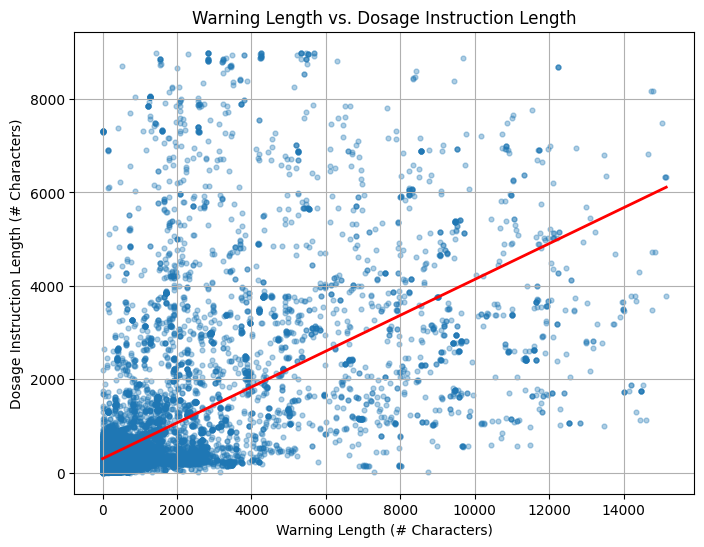

In [117]:
# To better visualize any relationship between the two variables, I removed extreme outliers and entries that were missing either warning or dosage & administration text (Correlation coefficient was calculated with the complete dataset)

plot_df = corr_df[
    (corr_df["warning_length"] > 0) &
    (corr_df["dosage_length"] > 0)
]

plot_df = plot_df[
    (plot_df["warning_length"] <= plot_df["warning_length"].quantile(0.99)) &
    (plot_df["dosage_length"] <= plot_df["dosage_length"].quantile(0.99))
]

plt.figure(figsize=(8,6))

plt.scatter(
    plot_df["warning_length"],
    plot_df["dosage_length"],
    alpha=0.35,
    s=12
)

# Line of best fit
m, b = np.polyfit(
    plot_df["warning_length"],
    plot_df["dosage_length"],
    1
)

x = np.linspace(
    plot_df["warning_length"].min(),
    plot_df["warning_length"].max(),
    100
)

plt.plot(
    x,
    m*x + b,
    color="red",
    linewidth=2,
    label="Best Fit Line"
)

plt.title("Warning Length vs. Dosage Instruction Length")
plt.xlabel("Warning Length (# Characters)")
plt.ylabel("Dosage Instruction Length (# Characters)")
plt.grid(True)

plt.show()

# The scatter plot shows a slight upward trend, even though there's a decent amount of variation amongst the data points. 
# The line of best fit also shows a weak positive correlation that is observed in the data. However, the large amount of points that are around the line of best fit show that the length of the warning label is not enough of a strong predictor of dosage instruction length.
